In [1]:
import os.path
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import os, time, json, math
from typing import List, Any, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from fasterrisk.fasterrisk import RiskScoreOptimizer, RiskScoreClassifier
from helpers import *

## Config

In [2]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'sct_found_after_comp', 'sct_perp_dia', 'sct_ab_gwth', 'missing_growth']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 58, 61, 64, 67],
    "sct_long_dia": [6, 8, 10, 15, 20, 30],
    "sct_perp_dia": [5, 7, 10, 12, 15, 20],
    "sct_ab_gwth": [2]
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex', 'sct_found_after_comp', 'missing_growth']

# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

## Read data

In [3]:
# 添加missing growth列
def add_growth_binary_col(df, source_col='sct_ab_growth', new_col='missing_growth'):
    if source_col in df.columns:
        growth = pd.to_numeric(df[source_col], errors='coerce')
    elif 'sct_ab_gwth' in df.columns:
        growth = pd.to_numeric(df['sct_ab_gwth'], errors='coerce')
    else:
        raise KeyError("Need either 'sct_ab_growth' or 'sct_ab_gwth' to build missing_growth.")

    df[new_col] = (growth == 9).astype(int)
    return df

In [4]:
# -------------------------
# Load, normalize/encode
# -------------------------
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

df1['sct_ab_gwth'] = df1['sct_ab_gwth'].fillna(0)
df2['sct_ab_gwth'] = df2['sct_ab_gwth'].fillna(0)


df1 = df1.dropna(subset=['sct_perp_dia'])
df2 = df2.dropna(subset=['sct_perp_dia'])

# -------------------------
# Patient-level stratified split (on df1)
# -------------------------
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

得到了三个未经binarize的df：train_df, val_df和df2

In [22]:
# 训练fasterrisk模型的函数。其中special_feature用于构建交互项
def train_fasterrisk(
    train_df,
    special_feature=None,
    sparsity_k=5,
    parent_size=50,
    gap_tolerance=0.15,
    select_top_m=100,
    max_attempts=200,
):
    """
    Train a FasterRisk model on the given train_df.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training data (must contain FEATURES_STLMD and LABEL_COL columns).
    special_feature : list[str] | str | None, optional
        Special feature list used to build interaction terms sequentially.
        At most 2 features are allowed. Defaults to ["missing_growth"].
    sparsity_k, parent_size, gap_tolerance, select_top_m, max_attempts :
        FasterRisk hyperparameters.

    Returns
    -------
    multipliers : np.ndarray
    beta0_int   : np.ndarray
    betas_int   : np.ndarray
    """
    if special_feature is None:
        special_features = ["missing_growth"]
    elif isinstance(special_feature, str):
        special_features = [special_feature]
    else:
        special_features = list(special_feature)

    if len(special_features) == 0:
        raise ValueError("special_feature cannot be empty")
    if len(special_features) > 2:
        raise ValueError("special_feature supports at most 2 features")

    # ---- prepare splits ----
    X_train_df, y_train_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)

    X_train_bin, _, _ = binarize_and_align_custom(
        X_train_df, X_train_df, X_train_df,
        feature_cuts={
            "age":          CUTS_CONT["age"],
            "sct_long_dia": CUTS_CONT["sct_long_dia"],
            "sct_perp_dia": CUTS_CONT["sct_perp_dia"],
            "sct_ab_gwth":  CUTS_CONT["sct_ab_gwth"],
        },
        passthrough_binary=BIN_PASSTHROUGH_STLMD,
    )

    for sf in special_features:
        if sf not in X_train_bin.columns:
            raise KeyError(f"special_feature '{sf}' not found after binarization")

    X_train_aug = X_train_bin.drop(columns=special_features, errors="ignore").copy()

    # 依次对 special_features 中每个 feature 构建交互项
    for sf in special_features:
        sf_train = pd.to_numeric(X_train_bin[sf], errors="coerce").fillna(0).astype(int)

        inter_train = X_train_aug.mul(sf_train, axis=0)
        inter_train.columns = [f"{c} x {sf}" for c in X_train_aug.columns]

        X_train_aug = pd.concat([X_train_aug, inter_train], axis=1)

    y_train = to_fastrisk_y(y_train_raw, pos_label=1)

    X_train = X_train_aug.to_numpy(dtype=float)

    # ---- optimize ----
    opt = make_optimizer(
        X=X_train, y=y_train,
        k=sparsity_k, parent_size=parent_size,
        gap_tolerance=gap_tolerance,
        select_top_m=select_top_m,
        max_attempts=max_attempts,
        want_intercept=True,
    )
    t0 = time.time()
    opt.optimize()
    print("Optimization takes {:.2f} seconds.".format(time.time() - t0))

    multipliers, beta0_int, betas_int = extract_models(opt.get_models())
    print("Generated {} risk score models from the sparse diverse pool.".format(len(multipliers)))

    plot_feature_model_matrix(betas_int, X_train_aug)

    return multipliers, beta0_int, betas_int

## growth==9作为binary

In [6]:
train_df9 = add_growth_binary_col(train_df)
val_df9 = add_growth_binary_col(val_df)
df29 = add_growth_binary_col(df2)

C:\Users\YiJin\AppData\Local\Temp\ipykernel_11772\2108199530.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = (growth == 9).astype(int)
C:\Users\YiJin\AppData\Local\Temp\ipykernel_11772\2108199530.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = (growth == 9).astype(int)


Optimization takes 282.74 seconds.
Generated 82 risk score models from the sparse diverse pool.


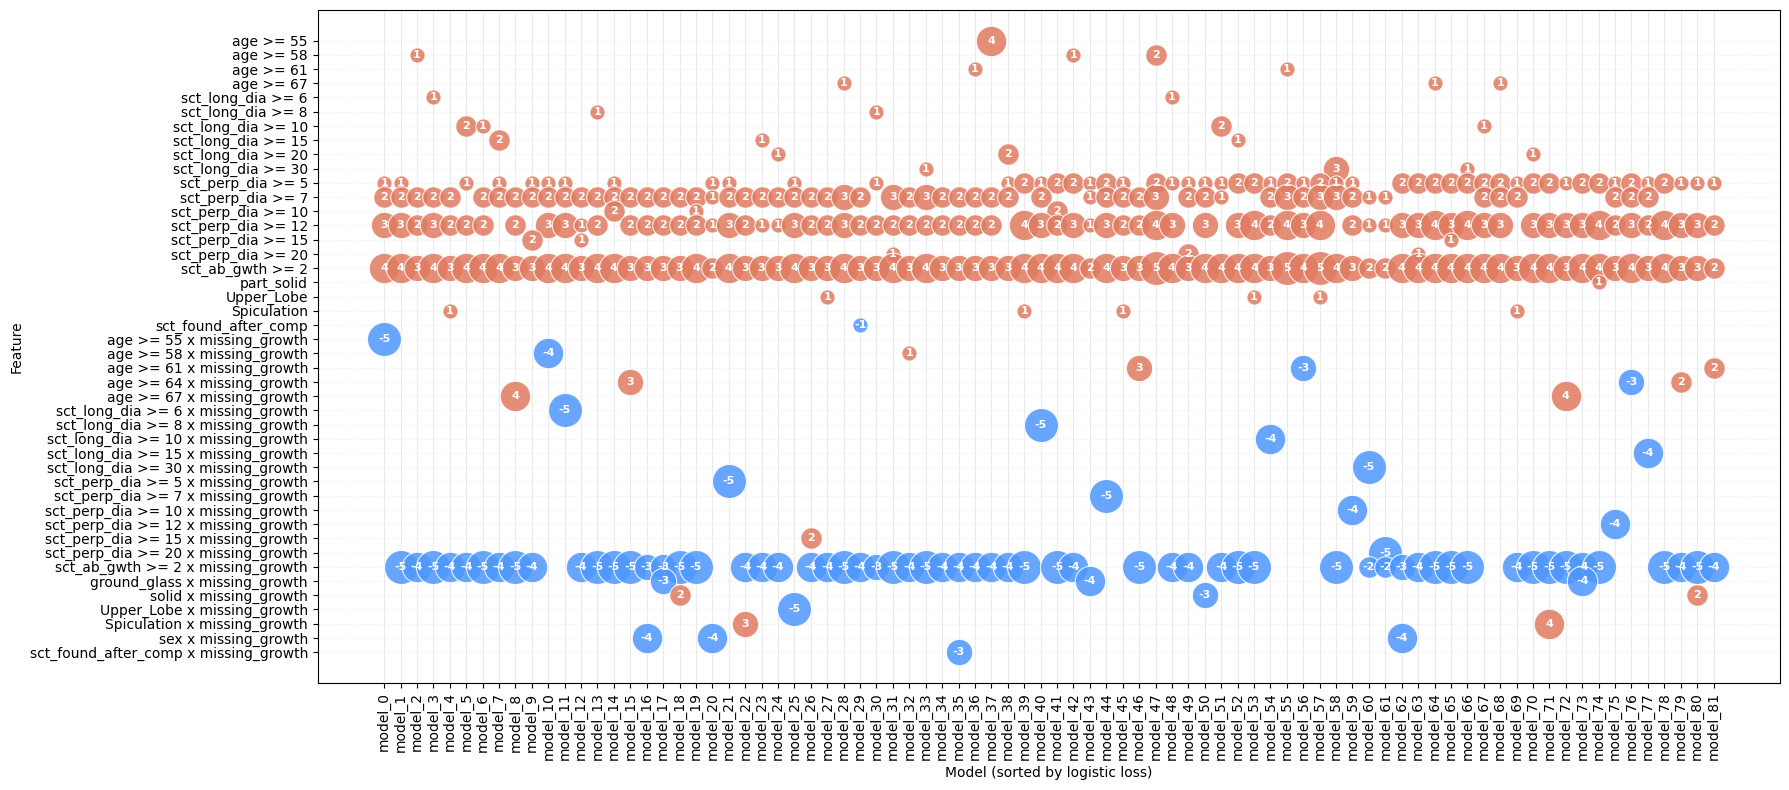

In [ ]:
multipliers, beta0_int, betas_int = train_fasterrisk(train_df9, special_feature=["missing_growth"])

In [34]:
def compute_auc_with_ci(
    multipliers, beta0_int, betas_int,
    test_data_dict: dict,
    train_df_for_align: pd.DataFrame,
    special_feature=None,
    ci=0.95,
    n_bootstrap=1000,
    random_state=42,
):
    """
    计算 FasterRisk 模型在多个测试集上的 AUC 及其置信区间。

    参数:
        multipliers: np.ndarray, 形状为 (n_models,)，每个模型的乘数
        beta0_int: np.ndarray, 形状为 (n_models,)，每个模型的截距
        betas_int: np.ndarray, 形状为 (n_models, n_features)，每个模型的系数
        test_data_dict: dict，键为数据集名称，值为测试集 DataFrame
        train_df_for_align: pd.DataFrame，用于构造与训练一致的二值特征列
        special_feature: list[str] | str | None，构建交互项的特征（最多2个）
        ci: float, 置信水平，默认 0.95 (即 95%)
        n_bootstrap: int, Bootstrap 迭代次数，默认 1000
        random_state: int, 随机种子，默认 42

    返回:
        pd.DataFrame，包含以下列：
            - dataset: str, 数据集名称
            - auc_mean: float, AUC 平均值
            - auc_ci_lower: float, AUC 置信区间下界
            - auc_ci_upper: float, AUC 置信区间上界
    """
    if special_feature is None:
        special_features = ["missing_growth"]
    elif isinstance(special_feature, str):
        special_features = [special_feature]
    else:
        special_features = list(special_feature)

    if len(special_features) == 0:
        raise ValueError("special_feature cannot be empty")
    if len(special_features) > 2:
        raise ValueError("special_feature supports at most 2 features")

    def augment_with_interactions(X_bin: pd.DataFrame, special_features: list[str]) -> pd.DataFrame:
        for sf in special_features:
            if sf not in X_bin.columns:
                raise KeyError(f"special_feature '{sf}' not found after binarization")

        X_aug = X_bin.drop(columns=special_features, errors="ignore").copy()

        # 与训练函数保持一致：按顺序逐个构建交互项，且每次基于当前扩展后的特征矩阵
        for sf in special_features:
            sf_vec = pd.to_numeric(X_bin[sf], errors="coerce").fillna(0).astype(int)
            inter = X_aug.mul(sf_vec, axis=0)
            inter.columns = [f"{c} x {sf}" for c in X_aug.columns]
            X_aug = pd.concat([X_aug, inter], axis=1)

        return X_aug

    results = []
    alpha = 1 - ci
    rng = np.random.default_rng(random_state)

    X_train_align_df, _ = prepare_data(train_df_for_align, FEATURES_STLMD, LABEL_COL)
    X_train_bin, _, _ = binarize_and_align_custom(
        X_train_align_df, X_train_align_df, X_train_align_df,
        feature_cuts={
            "age": CUTS_CONT["age"],
            "sct_long_dia": CUTS_CONT["sct_long_dia"],
            "sct_perp_dia": CUTS_CONT["sct_perp_dia"],
            "sct_ab_gwth": CUTS_CONT["sct_ab_gwth"],
        },
        passthrough_binary=BIN_PASSTHROUGH_STLMD,
    )
    X_train_aug_ref = augment_with_interactions(X_train_bin, special_features)

    for dataset_name, test_df in test_data_dict.items():
        # 从测试 DataFrame 生成 X_test 与 y_test
        X_test_df, y_test_raw = prepare_data(test_df, FEATURES_STLMD, LABEL_COL)

        _, _, X_test_bin = binarize_and_align_custom(
            X_train_align_df, X_test_df, X_test_df,
            feature_cuts={
                "age": CUTS_CONT["age"],
                "sct_long_dia": CUTS_CONT["sct_long_dia"],
                "sct_perp_dia": CUTS_CONT["sct_perp_dia"],
                "sct_ab_gwth": CUTS_CONT["sct_ab_gwth"],
            },
            passthrough_binary=BIN_PASSTHROUGH_STLMD,
        )

        X_test_aug = augment_with_interactions(X_test_bin, special_features)
        # 保证测试特征顺序与训练一致
        X_test_aug = X_test_aug.reindex(columns=X_train_aug_ref.columns, fill_value=0)

        y_test = to_fastrisk_y(y_test_raw, pos_label=1)
        y_test_01 = (y_test + 1.0) / 2.0
        X_test = X_test_aug.to_numpy(dtype=float)
        n_samples = X_test.shape[0]

        # 计算所有模型的预测概率
        n_models = len(multipliers)
        prob_matrix = np.zeros((n_samples, n_models))

        for i in range(n_models):
            mult = float(multipliers[i])
            b0 = float(beta0_int[i])
            betas = np.asarray(betas_int[i], dtype=int)
            probs = model_probs(mult, b0, betas, X_test)
            prob_matrix[:, i] = probs

        # 集合预测（所有模型的平均概率）
        ensemble_probs = prob_matrix.mean(axis=1)

        # 原始 AUC
        fpr, tpr, _ = roc_curve(y_test_01, ensemble_probs)
        auc_original = auc(fpr, tpr)

        # Bootstrap 置信区间
        bootstrap_aucs = []
        for _ in range(n_bootstrap):
            indices = rng.choice(n_samples, size=n_samples, replace=True)
            y_boot = y_test_01[indices]
            probs_boot = ensemble_probs[indices]

            # 跳过单类样本，避免 roc_curve 报错
            if np.unique(y_boot).size < 2:
                continue

            fpr_boot, tpr_boot, _ = roc_curve(y_boot, probs_boot)
            auc_boot = auc(fpr_boot, tpr_boot)
            bootstrap_aucs.append(auc_boot)

        if len(bootstrap_aucs) == 0:
            ci_lower, ci_upper = np.nan, np.nan
        else:
            bootstrap_aucs = np.array(bootstrap_aucs)
            lower_percentile = (alpha / 2) * 100
            upper_percentile = (1 - alpha / 2) * 100
            ci_lower = np.percentile(bootstrap_aucs, lower_percentile)
            ci_upper = np.percentile(bootstrap_aucs, upper_percentile)

        results.append({
            "dataset": dataset_name,
            "auc_mean": float(auc_original),
            "auc_ci_lower": float(ci_lower) if not np.isnan(ci_lower) else np.nan,
            "auc_ci_upper": float(ci_upper) if not np.isnan(ci_upper) else np.nan,
        })

    return pd.DataFrame(results)

In [9]:
test_data_dict = {
        "all": df29,
        "1st_scr": df29[df29["study_yr"] == 0].copy(),
        "rest_scr": df29[df29["study_yr"] != 0].copy(),
    }

auc_bootstrap_df = compute_bootstrap_auc_summary(
    multipliers=multipliers,
    beta0_int=beta0_int,
    betas_int=betas_int,
    test_data_dict=test_data_dict,
    train_df_for_align=train_df9,
    special_feature="missing_growth",
    ci=0.95,
    n_bootstrap=1000,
    random_state=42,
)

print("Output shape:", auc_bootstrap_df.shape)
display(auc_bootstrap_df.round(4))

Output shape: (3, 3)


,auc_mean_bootstrap,auc_ci_lower,auc_ci_upper
all,0.7665,0.7503,0.7830
1st_scr,0.8075,0.7698,0.8413
rest_scr,0.7582,0.7399,0.7765


## 

## 1st screening + exist previously

In [23]:
def add_fst_scr_feature(df1):
    """Add binary feature `fst_scr`: 1 when study_yr == 0, else 0."""
    df1 = df1.copy()
    df1["fst_scr"] = (df1["study_yr"] == 0).astype(int)
    return df1

In [24]:
def add_ext_prev_feature(df1):
    """Add binary feature `ext_prev`: first row in each pid group is 0, others are 1."""
    df1 = df1.copy()
    df1["ext_prev"] = (df1.groupby("pid").cumcount() > 0).astype(int)
    return df1

In [25]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'sct_found_after_comp', 'sct_perp_dia', 'sct_ab_gwth', 'fst_scr', 'ext_prev']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 58, 61, 64, 67],
    "sct_long_dia": [6, 8, 10, 15, 20, 30],
    "sct_perp_dia": [5, 7, 10, 12, 15, 20],
    "sct_ab_gwth": [2]
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex', 'sct_found_after_comp', 'fst_scr', 'ext_prev']

# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

In [26]:
train_df_gam = add_fst_scr_feature(train_df)
train_df_gam = add_ext_prev_feature(train_df_gam)

df2_gam = add_fst_scr_feature(df2)
df2_gam = add_ext_prev_feature(df2_gam)

Optimization takes 296.10 seconds.
Generated 85 risk score models from the sparse diverse pool.


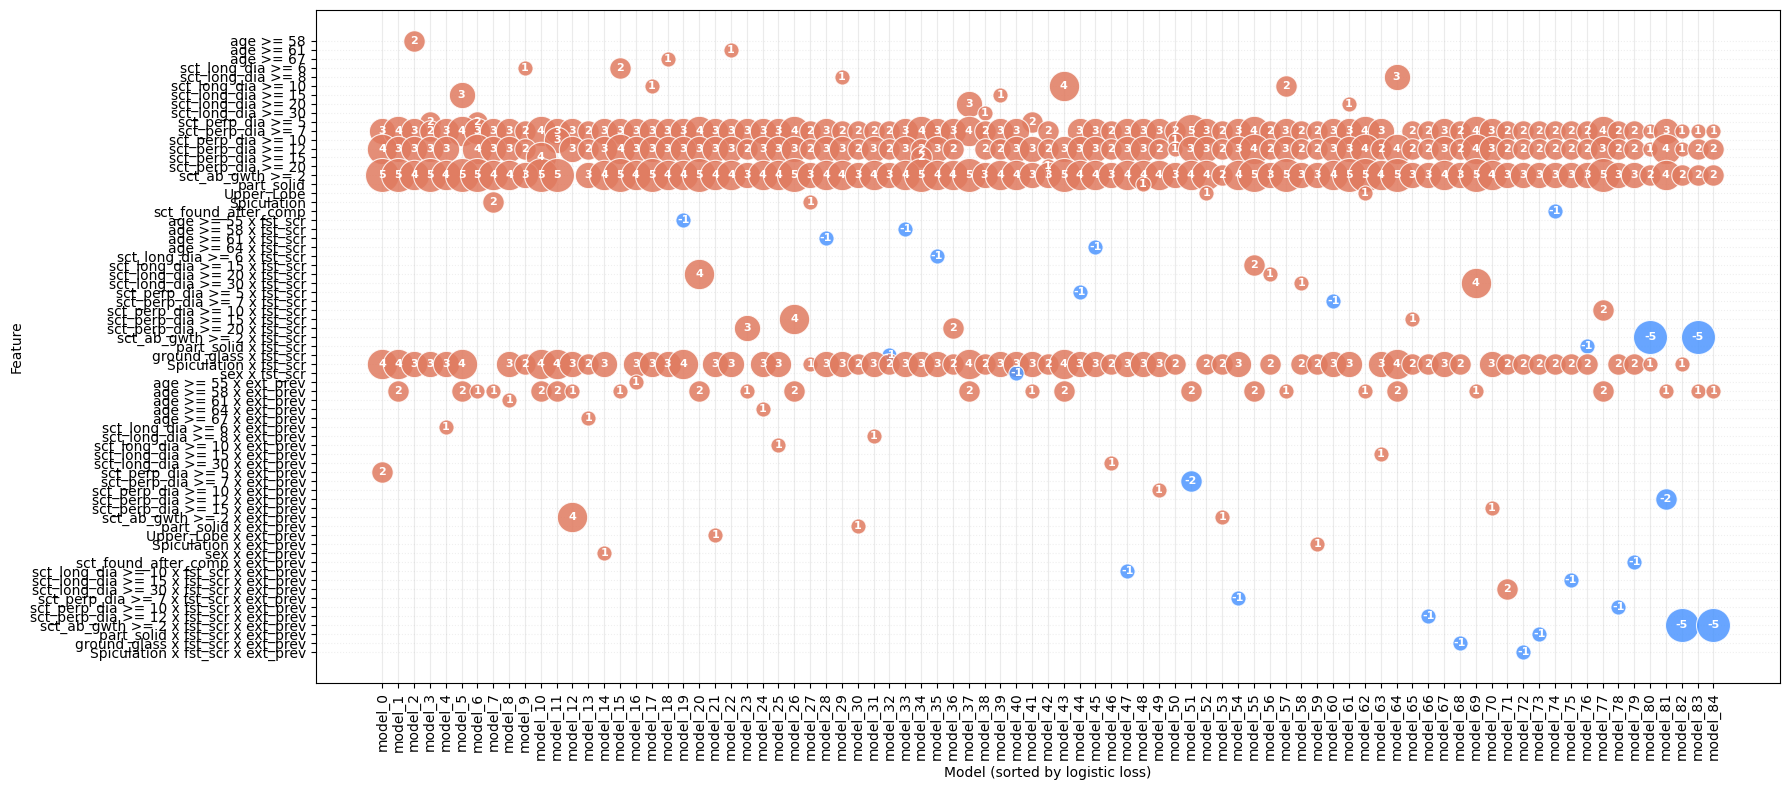

In [27]:
multipliers, beta0_int, betas_int = train_fasterrisk(train_df_gam, special_feature=["fst_scr", "ext_prev"])

Optimization takes 81.57 seconds.
Generated 81 risk score models from the sparse diverse pool.
Optimization takes 219.03 seconds.
Generated 68 risk score models from the sparse diverse pool.


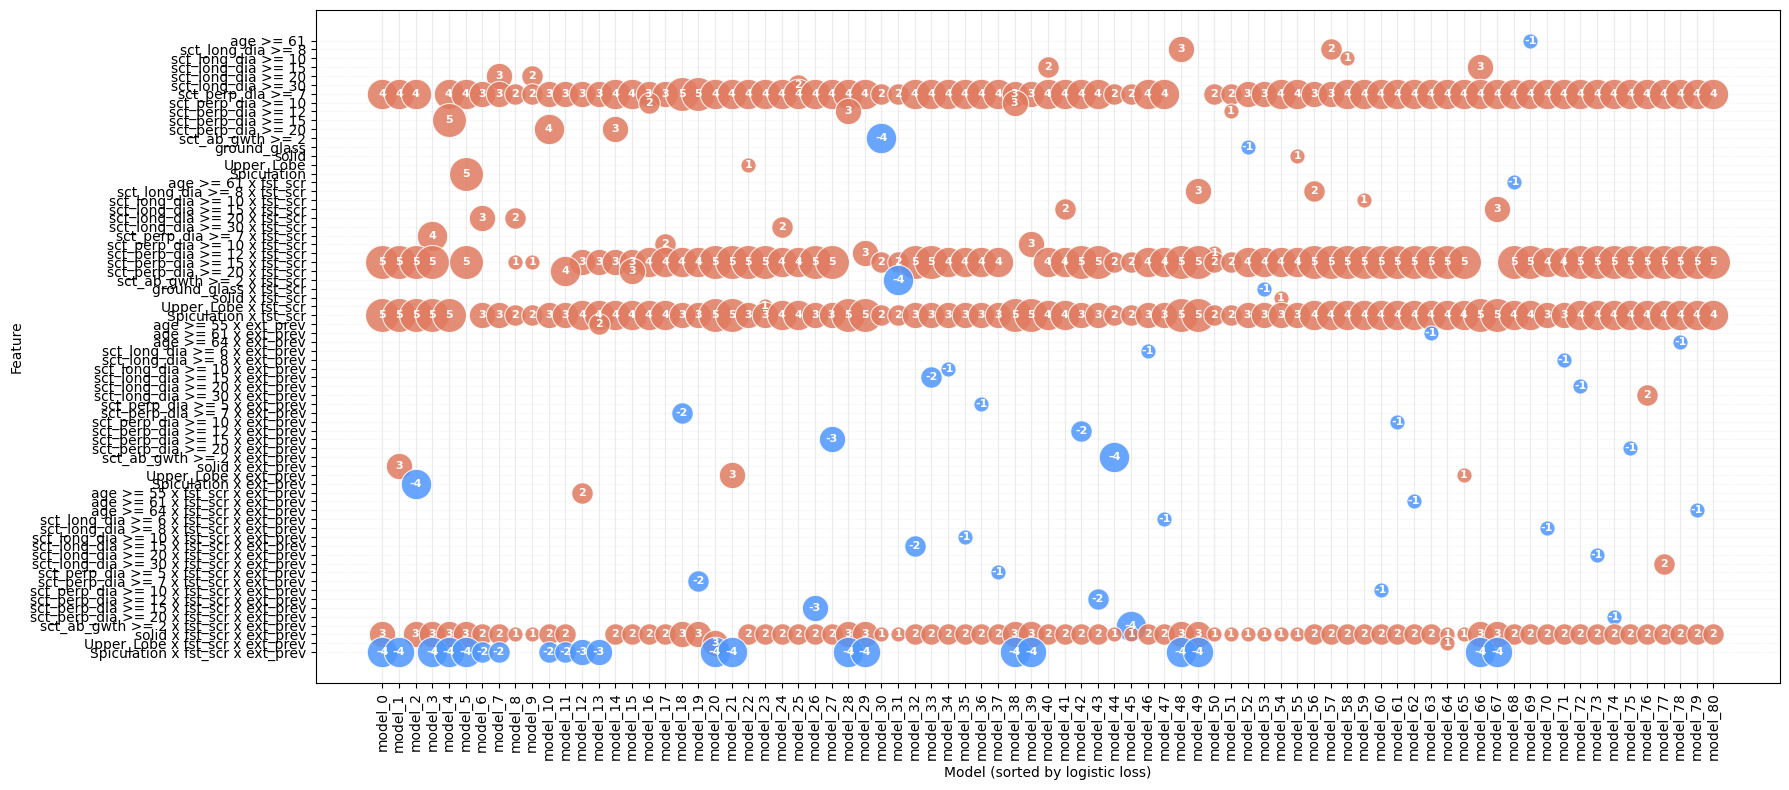

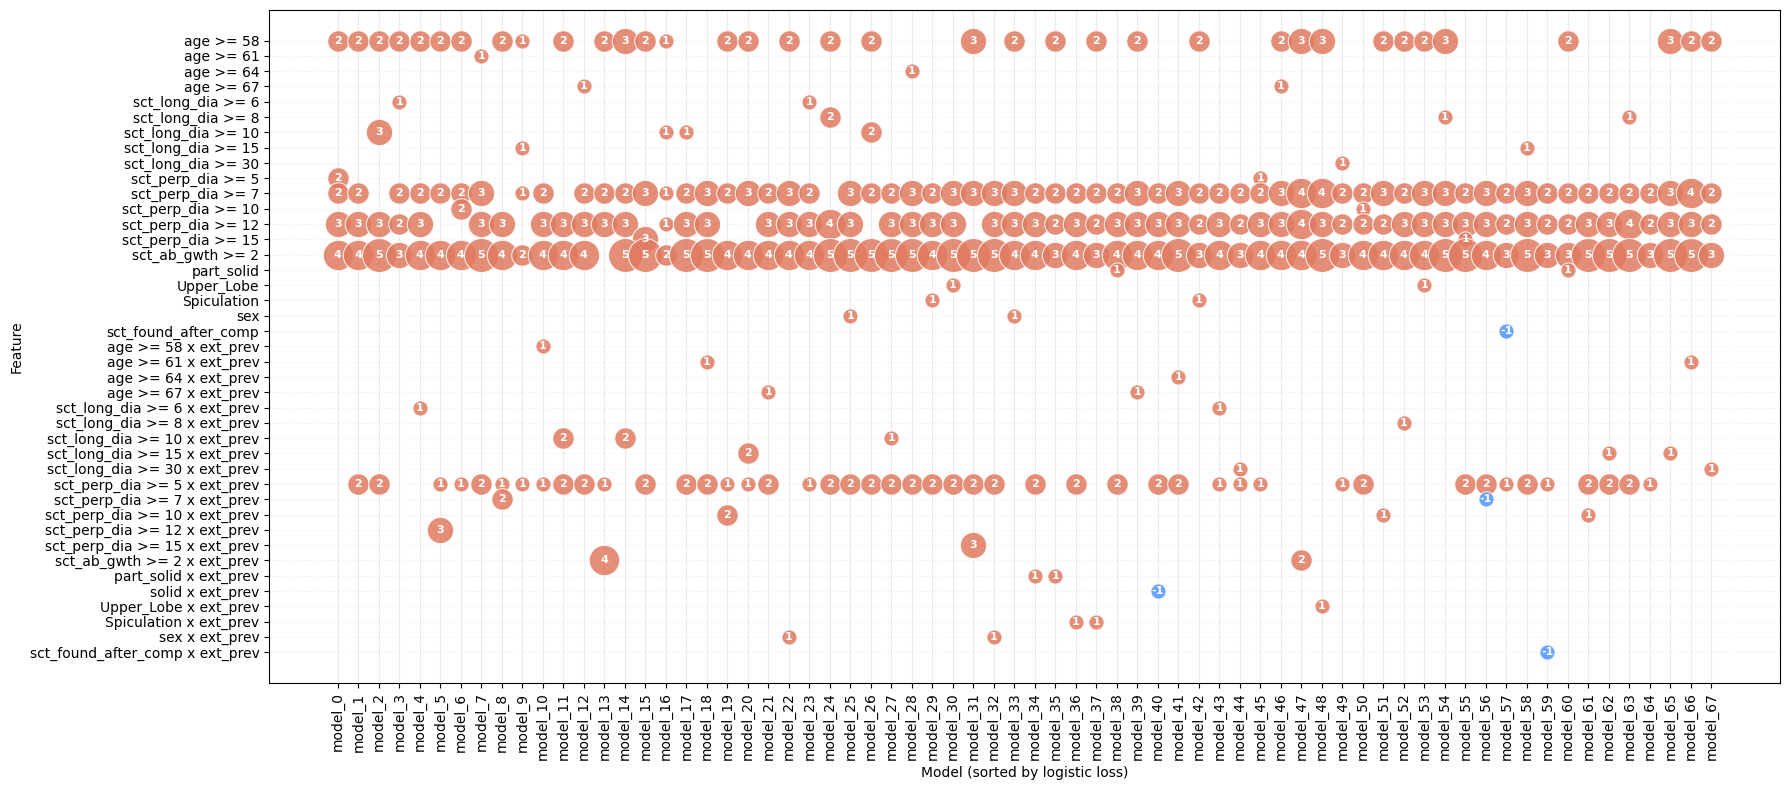

In [29]:
train_df_gam1 = train_df_gam[train_df_gam['study_yr'] == 0].copy()
train_df_gam2 = train_df_gam[train_df_gam['study_yr'] != 0].copy()
multipliers1, beta0_int1, betas_int1 = train_fasterrisk(train_df_gam1, special_feature=["fst_scr", "ext_prev"])
multipliers2, beta0_int2, betas_int2 = train_fasterrisk(train_df_gam2, special_feature=["fst_scr", "ext_prev"])

In [30]:
def transform_auc_df(df, ci_col_name):
    """
    Convert a 4-column dataframe into 2 columns:
    - keep the first column unchanged (e.g., dataset)
    - merge the next three columns into one CI string column
    """
    if df.shape[1] != 4:
        raise ValueError("Input dataframe must have exactly 4 columns.")

    first_col = df.columns[0]
    mean_col, lower_col, upper_col = df.columns[1:4]

    def _fmt(x):
        return f"{x:.2f}" if pd.notna(x) else "NA"

    out_df = df[[first_col]].copy()
    out_df[ci_col_name] = (
        df[mean_col].map(_fmt)
        + " ("
        + df[lower_col].map(_fmt)
        + ", "
        + df[upper_col].map(_fmt)
        + ")"
    )
    return out_df

In [35]:
test_data_dict = {
    "all": df2_gam,
    "1st_scr": df2_gam[df2_gam["study_yr"] == 0].copy(),
    "rest_scr": df2_gam[df2_gam["study_yr"] != 0].copy(),
}

auc_ci_df = compute_auc_with_ci(
    multipliers, beta0_int, betas_int,
    test_data_dict=test_data_dict,
    train_df_for_align=train_df_gam,
    special_feature=["fst_scr", "ext_prev"],
    ci=0.95,
    n_bootstrap=1000,
 )
auc_ci_df1 = compute_auc_with_ci(
    multipliers1, beta0_int1, betas_int1,
    test_data_dict=test_data_dict,
    train_df_for_align=train_df_gam1,
    special_feature=["fst_scr", "ext_prev"],
    ci=0.95,
    n_bootstrap=1000,
)
auc_ci_df2 = compute_auc_with_ci(
    multipliers2, beta0_int2, betas_int2,
    test_data_dict=test_data_dict,
    train_df_for_align=train_df_gam2,
    special_feature=["fst_scr", "ext_prev"],
    ci=0.95,
    n_bootstrap=1000,
)

In [45]:
fstrsk_all = transform_auc_df(auc_ci_df, "fstrsk_all")
fstrsk_1st = transform_auc_df(auc_ci_df1, "fstrsk_1st")
fstrsk_rest = transform_auc_df(auc_ci_df2, "fstrsk_rest")

fstrsk_merged = fstrsk_all.merge(fstrsk_1st, on="dataset").merge(fstrsk_rest, on="dataset")
fstrsk_merged.style.hide(axis="index").set_caption("FasterRisk missing feature").set_properties(**{"text-align":"center","padding":"6px","background-color":"#050D14"}).set_table_styles([{"selector":"th","props":[("background-color","#1f2937"),("color","white"),("text-align","center")]}])

dataset,fstrsk_all,fstrsk_1st,fstrsk_rest
all,"0.76 (0.74, 0.78)","0.67 (0.65, 0.69)","0.76 (0.74, 0.78)"
1st_scr,"0.81 (0.78, 0.84)","0.79 (0.76, 0.83)","0.80 (0.76, 0.83)"
rest_scr,"0.75 (0.73, 0.76)","0.64 (0.62, 0.66)","0.75 (0.73, 0.77)"
